/tmp/ipykernel_58/229586378.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_58/229586378.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




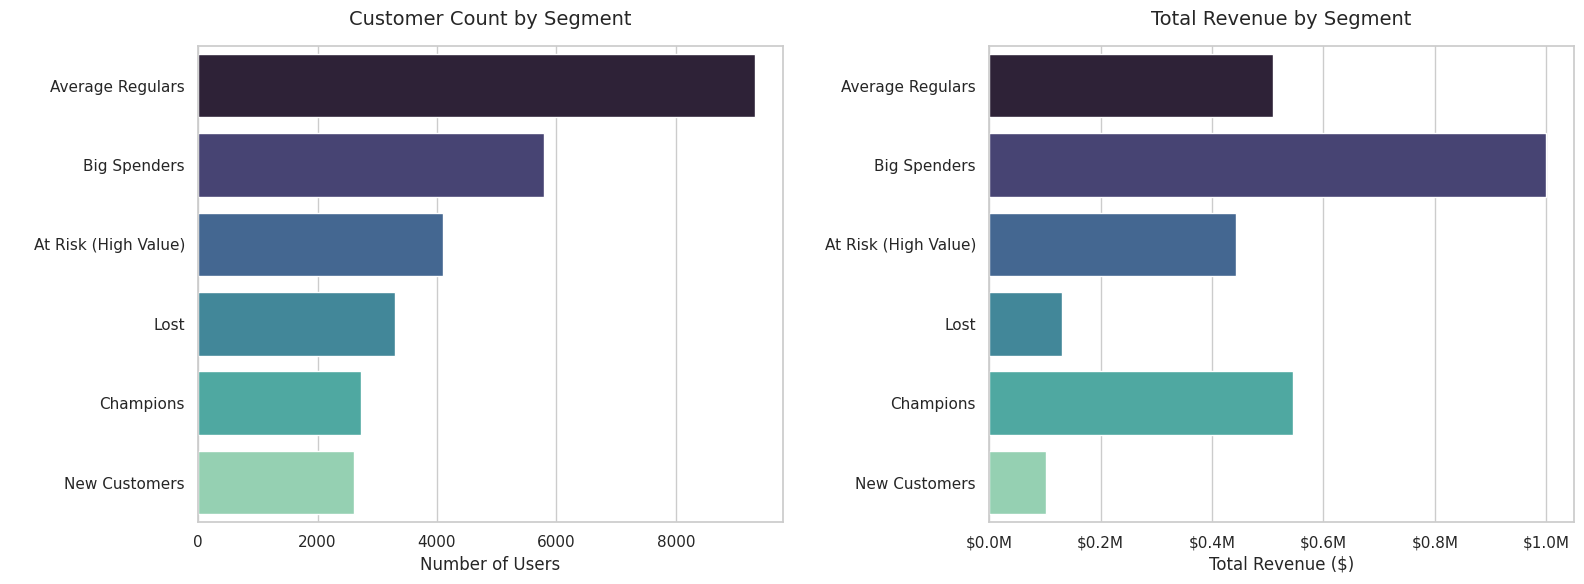

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

df = pd.read_csv('/kaggle/input/datasets/ivannathanael/01-rfm-segmentation/01_rfm_segmentation.csv')

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1,2,figsize=(16,6))

#Chart 1: Population Size
order_counts = df['customer_segment'].value_counts().index
sns.countplot(data=df, y='customer_segment', order=order_counts, palette='mako',ax=axes[0])
axes[0].set_title("Customer Count by Segment", fontsize=14, pad=15)
axes[0].set_xlabel('Number of Users')
axes[0].set_ylabel(" ")

#Chart 2: Monetary Contribution
revenue_df = df.groupby('customer_segment')['monetary'].sum().reindex(order_counts).reset_index()
sns.barplot(data=revenue_df, y='customer_segment', x='monetary', palette='mako', ax=axes[1])
axes[1].set_title("Total Revenue by Segment", fontsize=14, pad=15)
axes[1].set_xlabel('Total Revenue ($)')
axes[1].set_ylabel(' ')
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

In [13]:
import plotly.express as px

rfm_agg = df.groupby('customer_segment').agg(
    user_count=('user_id', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_recency=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean')
).reset_index()

fig = px.treemap(
    rfm_agg,
    path=[px.Constant('All Customers'), 'customer_segment'],
    values='user_count', # Size of the box = number of users
    color='total_revenue', # Color intensity = revenue generated
    hover_data={
        'total_revenue':':$,.0f',
        'avg_recency':':.1f',
        'avg_frequency':':.1f'
    },
    color_continuous_scale='Blues',
    title='RFM Segments: User Volume vs Revenue Contribution'
)

fig.update_layout(
    margin=dict(t=60, l=20, r=20, b=20),
    title_font_size=18,
    height=600
)

fig.update_layout(coloraxis_colorbar_title_text='Total Revenue ($)')
fig.show()

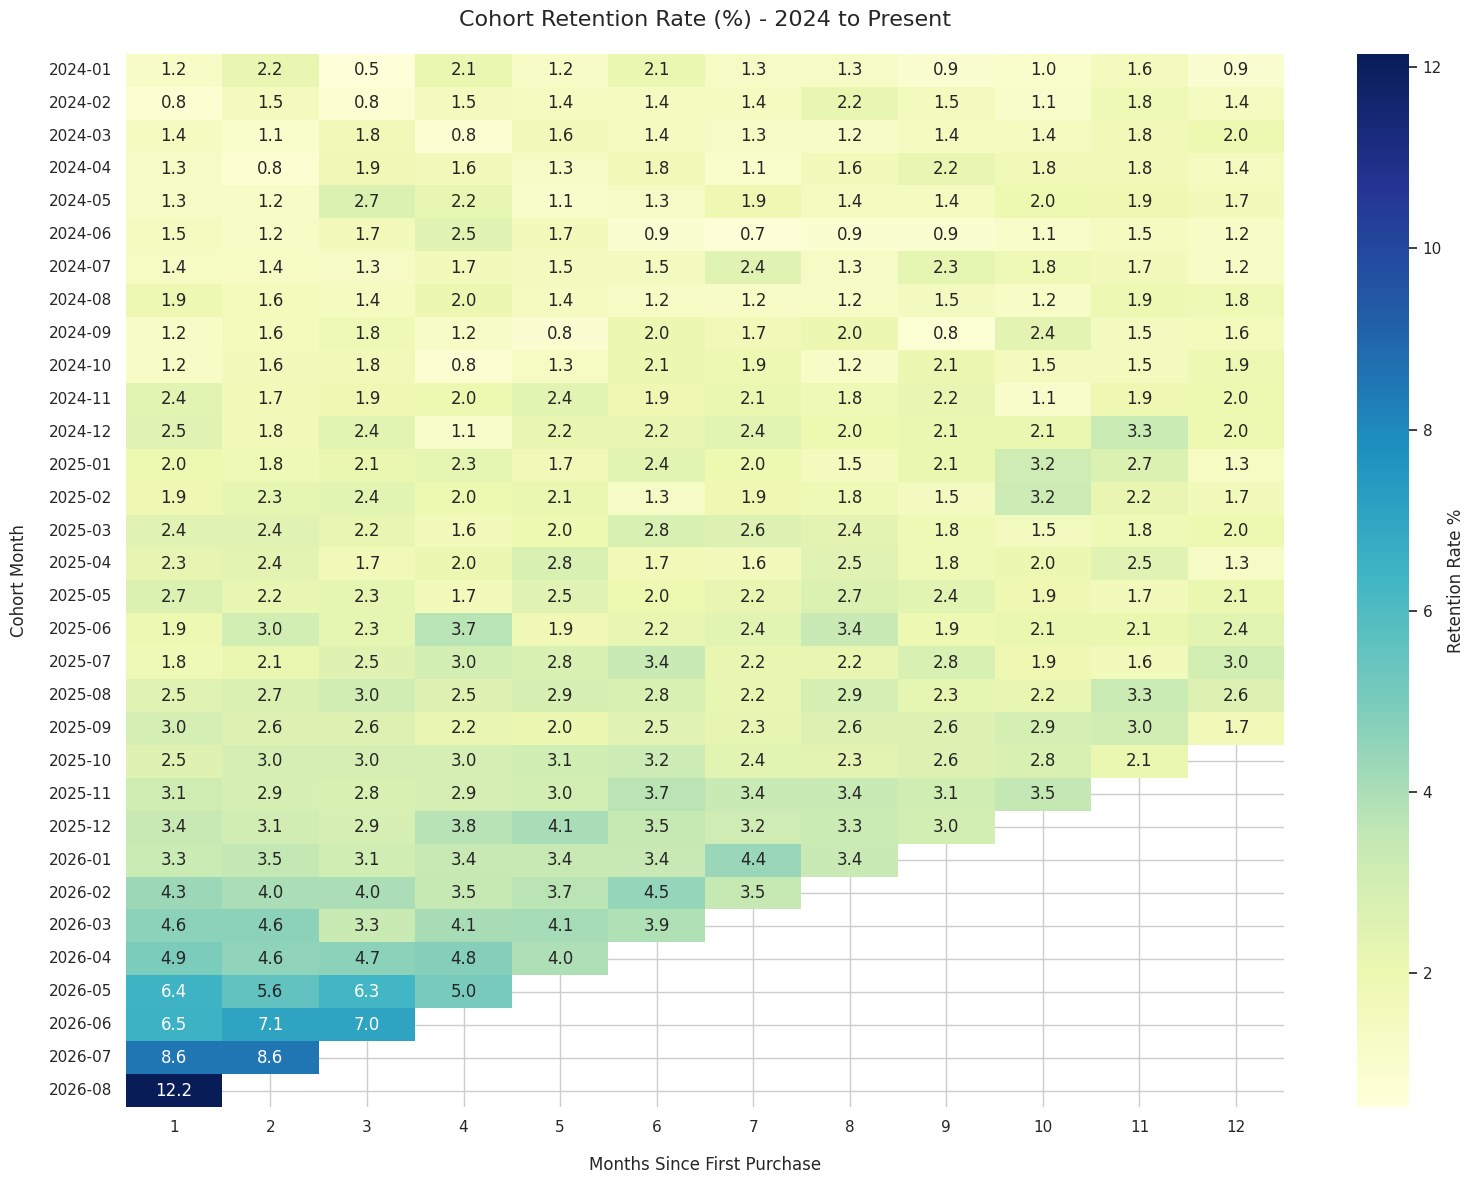

In [19]:
df_cohort = pd.read_csv('/kaggle/input/datasets/ivannathanael/02-cohort-retention/02_cohort_retention.csv')

# 1. Drop Month 0. It is always 100% and ruins the analytical color scale.
df_cohort = df_cohort[df_cohort['month_index'] > 0]

# Pivot the data
retention_matrix = df_cohort.pivot(index='cohort_month', columns='month_index', values='retention_rate_pct')

# 2. Keep only the first 12 months of retention
if retention_matrix.shape[1] > 12:
    retention_matrix = retention_matrix.iloc[:, :12] 

# Format the index
retention_matrix.index = pd.to_datetime(retention_matrix.index).strftime('%Y-%m')

# 3. Filter Y-axis to recent cohorts (2024 onwards) for readability
retention_matrix = retention_matrix.loc['2024-01':]

plt.figure(figsize=(16, 12))
# Fixed the title string error
plt.title('Cohort Retention Rate (%) - 2024 to Present', fontsize=16, pad=20)

sns.heatmap(
    retention_matrix, 
    annot=True,          
    fmt='.1f',           
    cmap='YlGnBu',       
    cbar_kws={'label': 'Retention Rate %'}
)

plt.xlabel('Months Since First Purchase', fontsize=12, labelpad=15)
plt.ylabel('Cohort Month', fontsize=12, labelpad=15)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

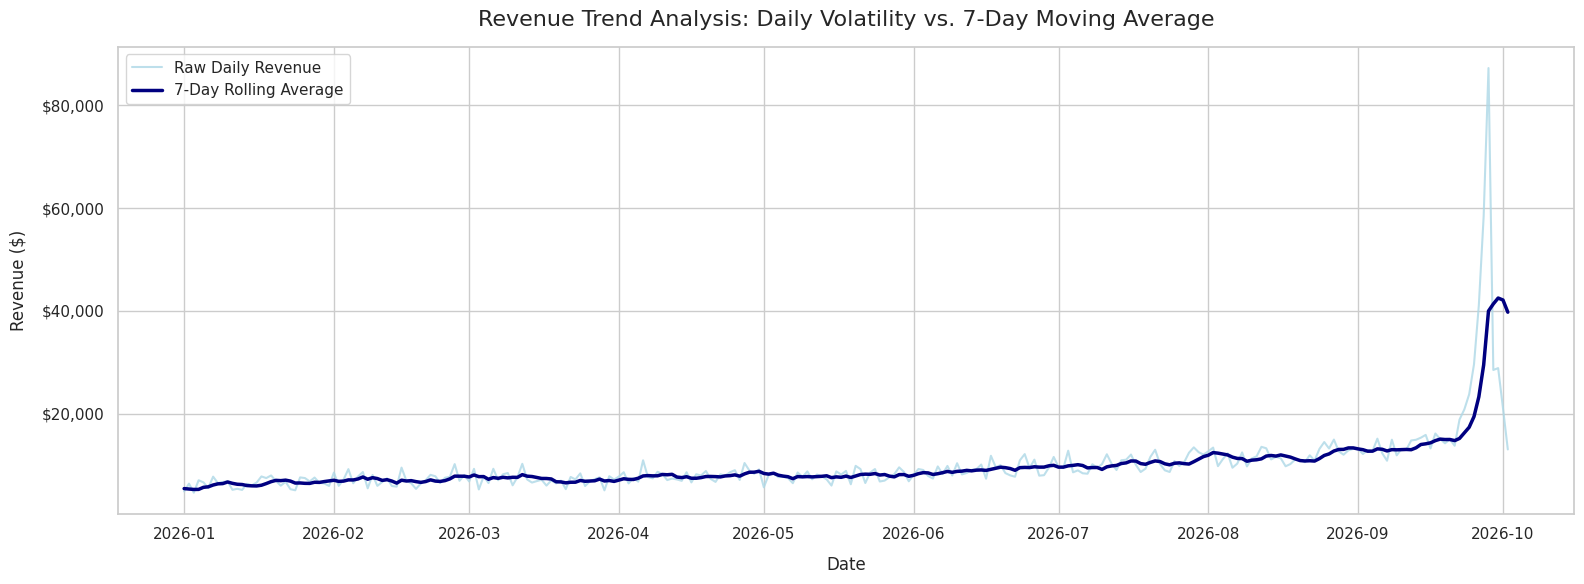

In [20]:
# Load the rolling revenue data
df_revenue = pd.read_csv('/kaggle/input/datasets/ivannathanael/03-rolling-revenue/03_rolling_revenue.csv') # Update path if needed

# Convert the calendar_date column to actual datetime objects
df_revenue['calendar_date'] = pd.to_datetime(df_revenue['calendar_date'])

# Filter to the most recent 6-8 months for visibility (adjust dates based on your actual max date)
# The dataset appears to end around Sept 2026, so let's look at 2026 year-to-date
df_recent = df_revenue[df_revenue['calendar_date'] >= '2026-01-01']

# Set up the plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Plot 1: The volatile raw daily revenue (faint background line)
sns.lineplot(
    data=df_recent, 
    x='calendar_date', 
    y='daily_revenue', 
    color='lightblue', 
    alpha=0.8, 
    label='Raw Daily Revenue'
)

# Plot 2: The smoothed 7-day rolling average (bold foreground line)
sns.lineplot(
    data=df_recent, 
    x='calendar_date', 
    y='rolling_7_day_avg', 
    color='navy', 
    linewidth=2.5, 
    label='7-Day Rolling Average'
)

# Formatting
plt.title('Revenue Trend Analysis: Daily Volatility vs. 7-Day Moving Average', fontsize=16, pad=15)
plt.xlabel('Date', fontsize=12, labelpad=10)
plt.ylabel('Revenue ($)', fontsize=12, labelpad=10)

# Format the Y-axis as currency
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'))

plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()